In [1]:
!date

Thu Jun 11 15:29:20 PDT 2026


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm
from scipy.stats import pearsonr
import os

In [3]:
projdir = '/u/project/cluo/terencew/claude/demux/pool_design'
srcdir  = '/u/project/cluo/terencew/demux_benchmark/pool_design'
dmx_dir = '/u/project/cluo/terencew/igvf/50_line/multiome/demux/wgs/demuxlet/gex/all_donors'
figdir  = f'{projdir}/figures'

In [4]:
dists = pd.read_csv(f'{srcdir}/csv/50_line/pool_genetic_dists.csv', sep='\t', index_col=0)
dists = dists.set_index('sample')
eth = pd.read_csv(f'{srcdir}/csv/50_line/pool_ancestries.csv', sep='\t', index_col=0)
eth.index = eth['sample']
eth['n_eur'] = (eth['eur_prop'] * 6).round().astype(int)
samples = dists.index.tolist()
print(len(samples))

63


In [5]:
### per-donor mean per-SNP LL-gap from demuxlet singlets
# group by SNG.BEST.GUESS (assigned donor ID) within each pool
def get_donor_ll(s):
    df = pd.read_csv(f'{dmx_dir}/{s}.best', sep='\t', index_col=0)
    sng = df[df['DROPLET.TYPE'] == 'SNG'].copy()
    sng['persnp_gap'] = sng['DIFF.LLK.BEST.NEXT'] / sng['NUM.SNPS']
    per_donor = sng.groupby('SNG.BEST.GUESS').agg(
        n_cells=('persnp_gap', 'count'),
        mean_persnp_gap=('persnp_gap', 'mean'),
        p05_persnp_gap=('persnp_gap', lambda x: np.percentile(x, 5)),
    ).reset_index()
    per_donor['sample'] = s
    per_donor = per_donor.rename(columns={'SNG.BEST.GUESS': 'donor'})
    return per_donor

with ProcessPoolExecutor() as executor:
    res = list(tqdm(executor.map(get_donor_ll, samples), total=len(samples)))

donor_ll = pd.concat(res, ignore_index=True)
print(donor_ll.shape)
donor_ll.head()

100%|██████████| 63/63 [00:00<00:00, 210.13it/s]


(1831, 5)


,donor,n_cells,mean_persnp_gap,p05_persnp_gap,sample
0,C1,555,0.043780,0.024263,IGVF50GEXA2
1,C11,1,-0.022000,-0.022000,IGVF50GEXA2
2,C12,1261,0.068771,0.020733,IGVF50GEXA2
3,C13,750,0.070415,0.040805,IGVF50GEXA2
4,C20,1525,0.069303,0.021380,IGVF50GEXA2


In [6]:
### load expected nearest-neighbor KL from 01a_expected_ll
donor_kl = pd.read_csv(f'{srcdir}/csv/50_line/donor_nn_kl.csv', sep='\t')
donor_kl.head()

,sample,donor,nn_kl
0,IGVF50GEXA2,C1,0.366685
1,IGVF50GEXA2,C12,0.373257
2,IGVF50GEXA2,C13,0.366685
3,IGVF50GEXA2,C20,0.280559
4,IGVF50GEXA2,C26,0.372957


In [7]:
### merge observed LL with expected KL
# donor name in SNG.BEST.GUESS is the line ID; nn_kl donor is the same ID
donor_df = donor_ll.merge(donor_kl, on=['sample', 'donor'], how='inner')
print(donor_df.shape)
donor_df.head()

(468, 6)


,donor,n_cells,mean_persnp_gap,p05_persnp_gap,sample,nn_kl
0,C1,555,0.043780,0.024263,IGVF50GEXA2,0.366685
1,C12,1261,0.068771,0.020733,IGVF50GEXA2,0.373257
2,C13,750,0.070415,0.040805,IGVF50GEXA2,0.366685
3,C20,1525,0.069303,0.021380,IGVF50GEXA2,0.280559
4,C26,838,0.074836,0.023404,IGVF50GEXA2,0.372957


In [8]:
### does nearest-neighbor KL predict per-donor observed LL-gap?
sub = donor_df[['nn_kl', 'mean_persnp_gap']].dropna()
r, p = pearsonr(sub['nn_kl'], sub['mean_persnp_gap'])
print(f'nn_kl vs mean_persnp_gap (per-donor): r={r:+.3f}  p={p:.4f}  n={len(sub)}')

sub2 = donor_df[['nn_kl', 'p05_persnp_gap']].dropna()
r2, p2 = pearsonr(sub2['nn_kl'], sub2['p05_persnp_gap'])
print(f'nn_kl vs p05_persnp_gap (per-donor): r={r2:+.3f}  p={p2:.4f}  n={len(sub2)}')

nn_kl vs mean_persnp_gap (per-donor): r=+0.213  p=0.0000  n=468
nn_kl vs p05_persnp_gap (per-donor): r=+0.111  p=0.0159  n=468


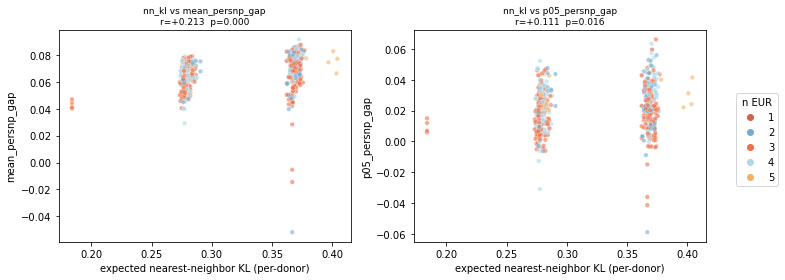

In [9]:
### scatter: expected KL vs observed per-donor LL-gap
pal = {0: '#4393c3', 1: '#d6604d', 2: '#74add1', 3: '#f46d43',
       4: '#abd9e9', 5: '#fdae61', 6: '#e0f3f8'}

tmp = donor_df.merge(eth[['n_eur']].reset_index(), on='sample', how='left')
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, oc in zip(axes, ['mean_persnp_gap', 'p05_persnp_gap']):
    sub = tmp[['nn_kl', oc, 'n_eur']].dropna()
    r, p = pearsonr(sub['nn_kl'], sub[oc])
    sns.scatterplot(data=sub, x='nn_kl', y=oc, hue='n_eur', palette=pal, ax=ax, alpha=0.6, s=20)
    ax.set_title(f'nn_kl vs {oc}\nr={r:+.3f}  p={p:.3f}', fontsize=9)
    ax.set_xlabel('expected nearest-neighbor KL (per-donor)')
    ax.set_ylabel(oc)
    ax.get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='n EUR', bbox_to_anchor=(1.02, 0.5), loc='center left')
plt.tight_layout()
os.makedirs(figdir, exist_ok=True)
fig.savefig(f'{figdir}/01h_donor_kl_vs_ll.pdf', bbox_inches='tight')

In [10]:
### identify bottleneck donor per pool (lowest mean per-SNP LL-gap)
bottleneck = (
    donor_df.loc[donor_df.groupby('sample')['mean_persnp_gap'].idxmin()]
    .set_index('sample')[['donor', 'mean_persnp_gap', 'nn_kl', 'n_cells']]
    .rename(columns={'mean_persnp_gap': 'btl_persnp_gap', 'nn_kl': 'btl_nn_kl'})
)
bottleneck.head()

,donor,btl_persnp_gap,btl_nn_kl,n_cells
sample,,,,
IGVF50GEXA2,C1,0.043780,0.366685,555
IGVF50GEXA3,C1,0.045553,0.366685,827
IGVF50GEXA4,C1,0.050163,0.363830,674
IGVF50GEXA5,C28,0.064065,0.281047,1856
IGVF50GEXB1,C24,0.070649,0.275389,3472


In [11]:
pool_df = bottleneck.join(dists[['mean', 'min']]).join(eth[['n_eur']])

for d in ['min', 'mean']:
    sub = pool_df[['btl_persnp_gap', d]].dropna()
    r, p = pearsonr(sub['btl_persnp_gap'], sub[d])
    print(f'bottleneck LL-gap vs {d} dist: r={r:+.3f}  p={p:.3f}')

sub_kl = pool_df[['btl_nn_kl', 'btl_persnp_gap']].dropna()
rk, pk = pearsonr(sub_kl['btl_nn_kl'], sub_kl['btl_persnp_gap'])
print(f'bottleneck nn_kl vs bottleneck LL-gap: r={rk:+.3f}  p={pk:.3f}')

bottleneck LL-gap vs min dist: r=+0.353  p=0.005
bottleneck LL-gap vs mean dist: r=-0.193  p=0.130
bottleneck nn_kl vs bottleneck LL-gap: r=-0.474  p=0.000


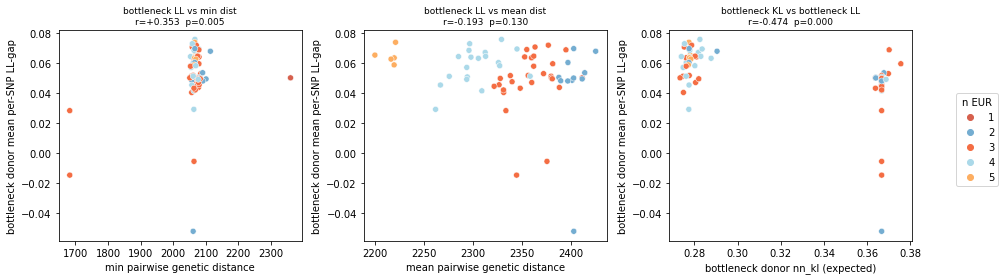

In [12]:
### scatter: bottleneck donor LL-gap vs pool min genetic distance
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# bottleneck LL vs min/mean dist
for ax, dc in zip(axes[:2], ['min', 'mean']):
    sub = pool_df[['btl_persnp_gap', dc, 'n_eur']].dropna().reset_index()
    r, p = pearsonr(sub['btl_persnp_gap'], sub[dc])
    sns.scatterplot(data=sub, x=dc, y='btl_persnp_gap', hue='n_eur', palette=pal, ax=ax)
    ax.set_title(f'bottleneck LL vs {dc} dist\nr={r:+.3f}  p={p:.3f}', fontsize=9)
    ax.set_xlabel(f'{dc} pairwise genetic distance')
    ax.set_ylabel('bottleneck donor mean per-SNP LL-gap')
    ax.get_legend().remove()

# bottleneck KL vs bottleneck LL
sub = pool_df[['btl_nn_kl', 'btl_persnp_gap', 'n_eur']].dropna().reset_index()
r, p = pearsonr(sub['btl_nn_kl'], sub['btl_persnp_gap'])
sns.scatterplot(data=sub, x='btl_nn_kl', y='btl_persnp_gap', hue='n_eur', palette=pal, ax=axes[2])
axes[2].set_title(f'bottleneck KL vs bottleneck LL\nr={r:+.3f}  p={p:.3f}', fontsize=9)
axes[2].set_xlabel('bottleneck donor nn_kl (expected)')
axes[2].set_ylabel('bottleneck donor mean per-SNP LL-gap')
axes[2].get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='n EUR', bbox_to_anchor=(1.02, 0.5), loc='center left')
plt.tight_layout()
fig.savefig(f'{figdir}/01h_bottleneck_donor.pdf', bbox_inches='tight')

In [13]:
### save per-donor LL gap table
out = f'{srcdir}/csv/50_line/donor_ll_gap.csv'
donor_df.to_csv(out, sep='\t', index=False)
print(f'saved {len(donor_df)} donor×pool rows → {out}')

saved 468 donor×pool rows → /u/project/cluo/terencew/demux_benchmark/pool_design/csv/50_line/donor_ll_gap.csv


In [14]:
!date

Thu Jun 11 15:29:25 PDT 2026
